# Regression

## First version

The initial version is building a dataset with statistical features, such as: q75's, std's or mean's.

And only trained with Linear Regression model.

Second version should contain motion features, trajectory or smoothness.

In [1]:
import pandas as pd

df = pd.read_csv("../../data/processed/dataset.csv")

print(df.shape)
print(df.head())


(217, 377)
                                           file_name    role  participant_id  \
0  DVST_XI_10-13_Nov_2025_12_10.36.46_expert_10_c...  expert              10   
1  DVST_XI_10-13_Nov_2025_12_10.36.46_expert_10_g...  expert              10   
2  DVST_XI_10-13_Nov_2025_12_10.36.46_expert_10_r...  expert              10   
3  DVST_XI_10-13_Nov_2025_12_10.36.46_expert_10_s...  expert              10   
4  DVST_XI_10-13_Nov_2025_12_10.36.46_expert_10_s...  expert              10   

                 task          task_clean  trial  n_timesteps  \
0       camera target       camera_target      1        14660   
1           glove cut           glove_cut      1        23620   
2  ring rollercoaster  ring_rollercoaster      1        31988   
3          sea spikes          sea_spikes      1        31692   
4              suture              suture      1        24064   

   duration_seconds  mean_dt_seconds  std_dt_seconds  ...  endoscope_11_max  \
0             71.64         0.004887  

In [2]:
drop_cols = [
    "file_name",
    "task",
    "task_clean",
    "role",
    "participant_id",
    "trial",
    "target_score",
    "percentage_score",
]

X = df.drop(columns=drop_cols)
y = df["target_score"]

X = X.select_dtypes(include="number")

print(X.shape)
print(y.shape)


(217, 369)
(217,)


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


(173, 369)
(44, 369)
(173,)
(44,)


In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(X_train.shape)
print(X_test.shape)


(173, 369)
(44, 369)


In [5]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

pred = model.predict(X_test)


In [6]:
import numpy as np

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("MAE:", mean_absolute_error(y_test, pred))
print("RMSE:", mean_squared_error(y_test, pred))
print("R2:", r2_score(y_test, pred))


MAE: 16.209538777397757
RMSE: 676.2290252813569
R2: -14.427520539060886


In [7]:
result = pd.DataFrame({
    "GroundTruth": y_test.values,
    "Prediction": pred
})

print(result.head(20))


    GroundTruth  Prediction
0          22.0   15.375635
1          22.0   13.974873
2          19.0   14.661800
3          26.0   26.043435
4           0.0   19.229615
5          14.0   11.743067
6          18.0   29.250446
7          13.0   10.208946
8          22.0   48.013493
9          12.0   39.362670
10         16.0   -5.245583
11         23.0   16.196363
12         23.0    0.796555
13         28.0   34.646595
14         22.0    3.244743
15         23.0   28.458063
16         21.0   23.040931
17         19.0   20.460592
18         15.0   14.603477
19         16.0   18.828498


In [8]:
coef = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coef = coef.sort_values(
    by="Coefficient",
    key=abs,
    ascending=False
)

print(coef.head(30))


                       Feature  Coefficient
222            usm_joint_8_q75   -11.790431
289  endoscope_4_diff_mean_abs   -10.114264
149           usm_joint_2_mean    -9.939969
358          endoscope_11_mean     9.906174
290       endoscope_4_diff_std     9.210733
145            usm_joint_1_q75     9.050129
179  usm_joint_4_diff_mean_abs     8.883484
155            usm_joint_2_q25     8.489676
265            endoscope_2_q25    -8.053341
248           endoscope_1_mean     7.539825
138           usm_joint_1_mean     7.433917
243            endoscope_0_q25    -7.376249
131         usm_joint_0_median     7.127561
244            endoscope_0_q75     6.786557
85                   suj_2_min    -6.613160
228            usm_joint_9_min    -6.612436
157  usm_joint_2_diff_mean_abs     6.152150
3               std_dt_seconds    -6.123394
148   usm_joint_1_diff_max_abs     6.093757
302   endoscope_5_diff_max_abs     6.012711
160           usm_joint_3_mean     6.005334
326            endoscope_8_std  

FileNotFoundError: [Errno 2] No such file or directory: 'results/pred_vs_gt.png'

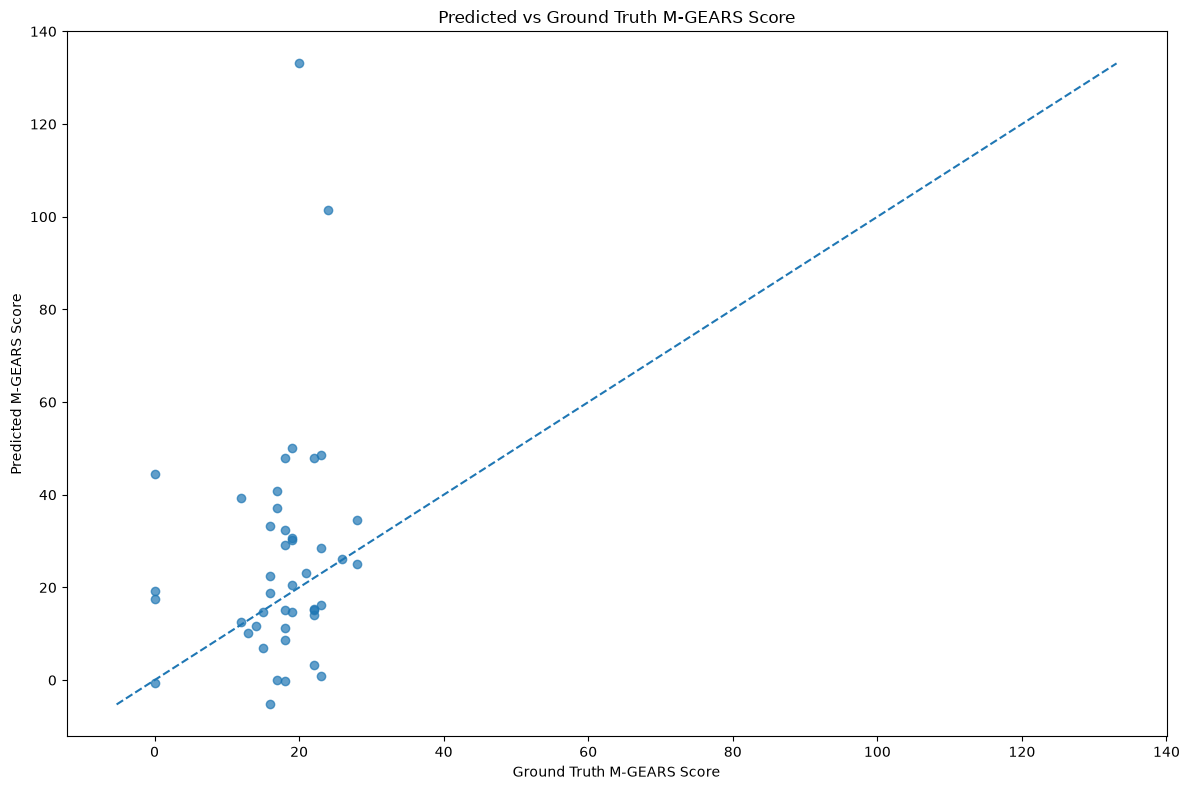

In [10]:
import matplotlib.pyplot as plt


plt.figure(figsize=(12, 8))
plt.scatter(y_test, pred, alpha=0.7)

min_val = min(y_test.min(), pred.min())
max_val = max(y_test.max(), pred.max())

# more points above, means overestimate; vice versa
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("Ground Truth M-GEARS Score")
plt.ylabel("Predicted M-GEARS Score")
plt.title("Predicted vs Ground Truth M-GEARS Score")

plt.tight_layout()
plt.savefig("results/pred_vs_gt.png", dpi=300)
plt.show()


## Second version

This version, we should try some "meaningful" motion features.

For surgical skill assessment,

| Feature           | Meaning                                 | Interpret                       | Metrics                                  |
|-------------------|-----------------------------------------|---------------------------------|------------------------------------------|
| Path Length       | How far the tool has traveled           | Expert: shorter, more efficient | path length                              |
| Mean Velocity     | dp/dt                                   | Expert: stabler                 | mean vel, max vel, std vel               |
| Acceleration      | Change of velocity over time            | Expert: not to sharp change     | mean accel, max accel                    |
| Jerk              | Classic metric for motion smoothness    | Expert: lower                   | jerk                                     |
| Idle Time         | Time the the tool stay still            | Expert: Less idle time          | idle ratio, idle duration                |

and also for camera features, we can do: endoscope stability, endoscope path, endoscope velocity.

And also for a better report aspect, we can do an ablation experiment：

| Feature Set      | MAE  | RMSE | R^2 |
|------------------|------|------|-----|
| Statistical Only | ...  | ...  | ... |
| + Motion         | ...  | ...  | ... |
| + Trajectory     | ...  | ...  | ... |
| + Camera         | ...  | ...  | ... |

And hence the experiment will show not only the model performance has improved, and also:

Which aspect of feature contributes more to predict M-GEARS?

This is more valuable for a paper, rather than just comparing a few models (Linear, Ridge, Random Forest).


### Some ideas

There are many surgery type, should we train for each surgery type?

## Next step

Analyse motion features. Which features could be calculated from the given data, and which contributes to the M-GEAR score?

In [1]:
import pandas as pd

df = pd.read_csv("../../data/processed/dataset_v2.csv")

print(df.shape)
print(df.columns.tolist()[:50])
print(df[["file_name", "role", "participant_id", "task_clean", "trial", "target_score"]].head())
print(df["task_clean"].value_counts())

(217, 72)
['file_name', 'role', 'participant_id', 'task', 'task_clean', 'trial', 'n_rows', 'n_unique_timestamps', 'duration_seconds', 'n_usms', 'USM0_n_samples', 'USM0_duration_seconds', 'USM0_path_length', 'USM0_mean_speed', 'USM0_max_speed', 'USM0_mean_acceleration', 'USM0_max_acceleration', 'USM0_idle_fraction', 'USM0_x_range', 'USM0_y_range', 'USM0_z_range', 'USM0_EA_xy', 'USM0_EA_xz', 'USM0_EA_yz', 'USM0_EV', 'USM1_n_samples', 'USM1_duration_seconds', 'USM1_path_length', 'USM1_mean_speed', 'USM1_max_speed', 'USM1_mean_acceleration', 'USM1_max_acceleration', 'USM1_idle_fraction', 'USM1_x_range', 'USM1_y_range', 'USM1_z_range', 'USM1_EA_xy', 'USM1_EA_xz', 'USM1_EA_yz', 'USM1_EV', 'USM2_n_samples', 'USM2_duration_seconds', 'USM2_path_length', 'USM2_mean_speed', 'USM2_max_speed', 'USM2_mean_acceleration', 'USM2_max_acceleration', 'USM2_idle_fraction', 'USM2_x_range', 'USM2_y_range']
                                           file_name    role  participant_id  \
0  DVST_XI_10-13_Nov_20

In [2]:
feature_cols = [
    "duration_seconds",
    "USM0_path_length",
    "USM1_path_length",
    "USM2_path_length",
    "USM3_path_length",
    "USM1_mean_speed",
    "USM2_mean_speed",
    "USM3_mean_speed",
    "USM1_idle_fraction",
    "USM2_idle_fraction",
    "USM3_idle_fraction",
]

print(df[feature_cols].describe().T)

                    count        mean         std       min         25%  \
duration_seconds    217.0  260.552166  150.670358  7.650000  162.920000   
USM0_path_length    217.0    2.924550    1.819232  0.000000    1.793967   
USM1_path_length    217.0   44.999163   27.515329  0.000000   25.674701   
USM2_path_length    217.0    7.338085    4.392241  0.000000    4.183482   
USM3_path_length    217.0   35.604706   31.556120  0.000000   12.380818   
USM1_mean_speed     217.0    0.198362    0.106139  0.000000    0.125801   
USM2_mean_speed     217.0    0.032487    0.017396  0.000000    0.021215   
USM3_mean_speed     217.0    0.156797    0.130044  0.000000    0.053623   
USM1_idle_fraction  217.0    0.145212    0.124799  0.001577    0.067298   
USM2_idle_fraction  217.0    0.246348    0.182982  0.008692    0.131669   
USM3_idle_fraction  217.0    0.247429    0.134098  0.025135    0.156336   

                           50%         75%         max  
duration_seconds    230.570000  322.750000

In [3]:
idle_cols = [
    "USM1_idle_fraction",
    "USM2_idle_fraction",
    "USM3_idle_fraction",
]

for col in idle_cols:
    print(col)
    print((df[col] == 1.0).sum(), "trials fully idle")
    print()

USM1_idle_fraction
1 trials fully idle

USM2_idle_fraction
1 trials fully idle

USM3_idle_fraction
1 trials fully idle



In [10]:
check_cols = [
    "duration_seconds",
    "USM0_path_length",
    "USM1_path_length",
    "USM2_path_length",
    "USM3_path_length",
    "USM1_mean_speed",
    "USM2_mean_speed",
    "USM3_mean_speed",
    "USM1_idle_fraction",
    "USM2_idle_fraction",
    "USM3_idle_fraction",
]

print(df[check_cols].isna().sum())
print()
print(df[check_cols].min())
print()
print(df[check_cols].max())

duration_seconds      0
USM0_path_length      0
USM1_path_length      0
USM2_path_length      0
USM3_path_length      0
USM1_mean_speed       0
USM2_mean_speed       0
USM3_mean_speed       0
USM1_idle_fraction    0
USM2_idle_fraction    0
USM3_idle_fraction    0
dtype: int64

duration_seconds      7.650000
USM0_path_length      0.000000
USM1_path_length      0.000000
USM2_path_length      0.000000
USM3_path_length      0.000000
USM1_mean_speed       0.000000
USM2_mean_speed       0.000000
USM3_mean_speed       0.000000
USM1_idle_fraction    0.001577
USM2_idle_fraction    0.008692
USM3_idle_fraction    0.025135
dtype: float64

duration_seconds      869.680000
USM0_path_length       10.446023
USM1_path_length      193.686739
USM2_path_length       28.442029
USM3_path_length      153.183047
USM1_mean_speed         0.662535
USM2_mean_speed         0.155552
USM3_mean_speed         0.731890
USM1_idle_fraction      1.000000
USM2_idle_fraction      1.000000
USM3_idle_fraction      1.000000
dt

In [5]:
idle_cols = [
    "USM1_idle_fraction",
    "USM2_idle_fraction",
    "USM3_idle_fraction",
]

meta_cols = [
    "file_name",
    "role",
    "participant_id",
    "task_clean",
    "trial",
    "target_score",
]

fully_idle_rows = df[
    (df[idle_cols] == 1.0).any(axis=1)
][meta_cols + idle_cols]

print(fully_idle_rows)

                                             file_name     role  \
113  DVST_XI_7-11_Mar_2024_09_10.19.01_trainee_10_c...  trainee   

     participant_id     task_clean  trial  target_score  USM1_idle_fraction  \
113              10  camera_target      1          14.0                 1.0   

     USM2_idle_fraction  USM3_idle_fraction  
113                 1.0                 1.0  


In [9]:
import pandas as pd

df = pd.read_csv("../../data/processed/dataset_v2.csv")

In [11]:
acc_cols = [
    "USM1_mean_acceleration",
    "USM2_mean_acceleration",
    "USM3_mean_acceleration",
    "USM1_max_acceleration",
    "USM2_max_acceleration",
    "USM3_max_acceleration",
]

print(df[acc_cols].describe().T)

                        count         mean          std  min         25%  \
USM1_mean_acceleration  217.0     5.773741     4.543077  0.0    3.133429   
USM2_mean_acceleration  217.0     1.152995     1.088966  0.0    0.560434   
USM3_mean_acceleration  217.0     5.540796     6.086913  0.0    1.633399   
USM1_max_acceleration   217.0  1485.799579  1603.843390  0.0  534.509807   
USM2_max_acceleration   217.0   417.247920   497.892042  0.0  188.901257   
USM3_max_acceleration   217.0  1614.087423  2025.636233  0.0  457.744643   

                               50%          75%           max  
USM1_mean_acceleration    4.532516     6.968895     30.243837  
USM2_mean_acceleration    0.900964     1.396034      8.560525  
USM3_mean_acceleration    4.026216     7.286161     41.844783  
USM1_max_acceleration   803.888754  1763.690765   9846.918974  
USM2_max_acceleration   294.736828   440.363500   4454.249016  
USM3_max_acceleration   924.580309  1929.265930  13305.932318  


In [12]:
row = df.loc[113]

cols = [
    "file_name",
    "task_clean",
    "target_score",
    "USM0_path_length",
    "USM0_mean_speed",
    "USM0_idle_fraction",
    "USM1_path_length",
    "USM2_path_length",
    "USM3_path_length",
    "USM1_idle_fraction",
    "USM2_idle_fraction",
    "USM3_idle_fraction",
]

print(row[cols])

file_name             DVST_XI_7-11_Mar_2024_09_10.19.01_trainee_10_c...
task_clean                                                camera_target
target_score                                                       14.0
USM0_path_length                                                    0.0
USM0_mean_speed                                                     0.0
USM0_idle_fraction                                                  1.0
USM1_path_length                                                    0.0
USM2_path_length                                                    0.0
USM3_path_length                                                    0.0
USM1_idle_fraction                                                  1.0
USM2_idle_fraction                                                  1.0
USM3_idle_fraction                                                  1.0
Name: 113, dtype: object


In [1]:
import pandas as pd

df = pd.read_csv("../../data/processed/dataset_v2.csv")

print(df.shape)

new_cols = [
    c for c in df.columns
    if (
        "jerk" in c
        or "smoothness" in c
        or "rotational" in c
        or "rotation_path" in c
        or "USM1_USM2" in c
        or "USM1_USM3" in c
        or "USM2_USM3" in c
        or "active_tool_count" in c
        or "all_usms" in c
    )
]

print(len(new_cols))
print(new_cols[:80])

(217, 139)
64
['USM0_mean_jerk', 'USM0_max_jerk', 'USM0_jerk_cost', 'USM0_normalized_jerk', 'USM0_smoothness_index', 'USM0_rotation_path_length', 'USM0_mean_rotational_velocity', 'USM0_max_rotational_velocity', 'USM0_mean_rotational_acceleration', 'USM0_max_rotational_acceleration', 'USM1_mean_jerk', 'USM1_max_jerk', 'USM1_jerk_cost', 'USM1_normalized_jerk', 'USM1_smoothness_index', 'USM1_rotation_path_length', 'USM1_mean_rotational_velocity', 'USM1_max_rotational_velocity', 'USM1_mean_rotational_acceleration', 'USM1_max_rotational_acceleration', 'USM2_mean_jerk', 'USM2_max_jerk', 'USM2_jerk_cost', 'USM2_normalized_jerk', 'USM2_smoothness_index', 'USM2_rotation_path_length', 'USM2_mean_rotational_velocity', 'USM2_max_rotational_velocity', 'USM2_mean_rotational_acceleration', 'USM2_max_rotational_acceleration', 'USM3_mean_jerk', 'USM3_max_jerk', 'USM3_jerk_cost', 'USM3_normalized_jerk', 'USM3_smoothness_index', 'USM3_rotation_path_length', 'USM3_mean_rotational_velocity', 'USM3_max_rota

In [2]:
import numpy as np
import pandas as pd

df = pd.read_csv("../../data/processed/dataset_v2.csv")

check_cols = [
    "duration_seconds",
    "USM1_path_length",
    "USM1_mean_speed",
    "USM1_mean_acceleration",
    "USM1_mean_jerk",
    "USM1_smoothness_index",
    "USM1_rotation_path_length",
    "USM1_mean_rotational_velocity",
    "USM1_USM2_mean_distance",
    "USM1_USM2_speed_correlation",
    "active_tool_count",
    "all_usms_path_length_total",
    "all_usms_fully_idle",
    "target_score",
]

print(df[check_cols].describe().T)
print("\nMissing values:")
print(df[check_cols].isna().sum())

print("\nInfinite values:")
print(np.isinf(df[check_cols].select_dtypes(include="number")).sum())

print("\nFully idle trials:")
print(df["all_usms_fully_idle"].value_counts())

                               count        mean         std       min  \
duration_seconds               217.0  260.552166  150.670358  7.650000   
USM1_path_length               217.0   44.999163   27.515329  0.000000   
USM1_mean_speed                217.0    0.198362    0.106139  0.000000   
USM1_mean_acceleration         217.0    6.413319    4.761258  0.000000   
USM1_mean_jerk                 217.0  571.575536  471.891483  0.000000   
USM1_smoothness_index          216.0    0.023913    0.001611  0.020383   
USM1_rotation_path_length      217.0   96.062214   52.608341  2.815007   
USM1_mean_rotational_velocity  217.0    0.412825    0.155893  0.085279   
USM1_USM2_mean_distance        217.0    1.131028    0.030166  0.851334   
USM1_USM2_speed_correlation    216.0    0.749382    0.099358  0.393638   
active_tool_count              217.0    2.986175    0.203653  0.000000   
all_usms_path_length_total     217.0   90.866504   57.541254  0.000000   
all_usms_fully_idle            217.0  

In [3]:
print(df[df["all_usms_fully_idle"] == 1][[
    "file_name",
    "role",
    "participant_id",
    "task_clean",
    "trial",
    "duration_seconds",
    "target_score",
    "all_usms_path_length_total",
    "active_tool_count",
]])

                                             file_name     role  \
113  DVST_XI_7-11_Mar_2024_09_10.19.01_trainee_10_c...  trainee   

     participant_id     task_clean  trial  duration_seconds  target_score  \
113              10  camera_target      1             35.78          14.0   

     all_usms_path_length_total  active_tool_count  
113                         0.0                  0  


In [4]:
print(df[df["target_score"] == 0][[
    "file_name",
    "role",
    "participant_id",
    "task_clean",
    "trial",
    "target_score",
    "percentage_score",
]])

                                             file_name     role  \
15   DVST_XI_14-16_Feb_2024_14_09.13.16_trainee_1_g...  trainee   
16   DVST_XI_14-16_Feb_2024_14_09.13.16_trainee_1_r...  trainee   
17   DVST_XI_14-16_Feb_2024_14_09.13.16_trainee_1_s...  trainee   
41   DVST_XI_14-16_Feb_2024_16_08.32.59_trainee_1_r...  trainee   
55   DVST_XI_14-16_Feb_2024_16_08.32.59_trainee_4_g...  trainee   
56   DVST_XI_14-16_Feb_2024_16_08.32.59_trainee_4_r...  trainee   
57   DVST_XI_14-16_Feb_2024_16_08.32.59_trainee_4_s...  trainee   
58   DVST_XI_14-16_Feb_2024_16_08.32.59_trainee_4_s...  trainee   
117  DVST_XI_7-11_Mar_2024_09_10.19.01_trainee_6_ca...  trainee   

     participant_id          task_clean  trial  target_score  percentage_score  
15                1           glove_cut      1           0.0               0.0  
16                1  ring_rollercoaster      1           0.0               0.0  
17                1          sea_spikes      1           0.0               0.0  
41   

In [1]:
print(df[df["target_score"] == 0]["file_name"])


NameError: name 'df' is not defined

In [2]:
import pandas as pd

df = pd.read_csv(r"C:\Users\ROG\IHE-project\data\processed\dataset_v3.csv")

In [3]:
print(df[df["target_score"] == 0]["file_name"])

15     DVST_XI_14-16_Feb_2024_14_09.13.16_trainee_1_g...
16     DVST_XI_14-16_Feb_2024_14_09.13.16_trainee_1_r...
17     DVST_XI_14-16_Feb_2024_14_09.13.16_trainee_1_s...
41     DVST_XI_14-16_Feb_2024_16_08.32.59_trainee_1_r...
55     DVST_XI_14-16_Feb_2024_16_08.32.59_trainee_4_g...
56     DVST_XI_14-16_Feb_2024_16_08.32.59_trainee_4_r...
57     DVST_XI_14-16_Feb_2024_16_08.32.59_trainee_4_s...
58     DVST_XI_14-16_Feb_2024_16_08.32.59_trainee_4_s...
117    DVST_XI_7-11_Mar_2024_09_10.19.01_trainee_6_ca...
Name: file_name, dtype: str


In [4]:
import pandas as pd
import glob

for f in glob.glob(r"C:\Users\ROG\IHE-project\Kinematics\dataset\Griffin_Training_Dataset\M-GEARS\*.csv"):
    df = pd.read_csv(f)

    if "Total operation M-GEARS score" in df.columns:
        score = df["Total operation M-GEARS score"].iloc[0]

        if score == 0:
            print(f)

C:\Users\ROG\IHE-project\Kinematics\dataset\Griffin_Training_Dataset\M-GEARS\M_GEARS_14-16_Feb_2024_14_09.13.16_trainee_1_glove cut_1.csv
C:\Users\ROG\IHE-project\Kinematics\dataset\Griffin_Training_Dataset\M-GEARS\M_GEARS_14-16_Feb_2024_14_09.13.16_trainee_1_ring rollercoaster_1.csv
C:\Users\ROG\IHE-project\Kinematics\dataset\Griffin_Training_Dataset\M-GEARS\M_GEARS_14-16_Feb_2024_14_09.13.16_trainee_1_sea spikes_1.csv
C:\Users\ROG\IHE-project\Kinematics\dataset\Griffin_Training_Dataset\M-GEARS\M_GEARS_14-16_Feb_2024_16_08.32.59_trainee_1_ring rollercoaster_2.csv
C:\Users\ROG\IHE-project\Kinematics\dataset\Griffin_Training_Dataset\M-GEARS\M_GEARS_14-16_Feb_2024_16_08.32.59_trainee_4_glove cut_2.csv
C:\Users\ROG\IHE-project\Kinematics\dataset\Griffin_Training_Dataset\M-GEARS\M_GEARS_14-16_Feb_2024_16_08.32.59_trainee_4_ring rollercoaster_2.csv
C:\Users\ROG\IHE-project\Kinematics\dataset\Griffin_Training_Dataset\M-GEARS\M_GEARS_14-16_Feb_2024_16_08.32.59_trainee_4_sea spikes_2.csv
C:\Us

In [5]:
C:\Users\ROG\IHE-project\scripts\qc_dataset_v3.py

SyntaxError: unexpected character after line continuation character (2453990391.py, line 1)